## 1. Business Understanding

In this project, I will build a machine learning model to forecast 3 months of 50 items sales in 10 different stores of a company. It involves supervised learning, using a labeled training set for time series forecasting.

I will use the following pipeline, based on CRISP-DM framework:

1. Businesss understanding
2. Data understanding
3. Data preparaton
4. Modelling
5. Evaluation
6. Deployment

In this notebook, I will be covering steps 1 and 2 of the pipeline above. The main objective here is to understand the business problem and assess the time series data (5 years of sales) trends, seasonal patterns and characteristics, which will guide the modelling step and provide valuable business insights. Furthermore, I will approach these steps in detail below, explaining why I am making each decision.

### Importing the libraies

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

## 2. Data Understanding

In [5]:
train_path = '/content/train.csv'

In [4]:
test_path = '/content/test.csv'

In [6]:
df_train = pd.read_csv(train_path)

In [7]:
df_test = pd.read_csv(test_path)

In [9]:
df_train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [10]:
df_train.tail()

,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


Data Dictionary

**DataFrame `df_train`:**

| Cột   | Kiểu dữ liệu | Mô tả                                  |
| :---- | :----------- | :------------------------------------- |
| date  | string       | Ngày ghi nhận doanh số                 |
| store | integer      | Mã định danh cửa hàng                  |
| item  | integer      | Mã định danh sản phẩm                  |
| sales | integer      | Số lượng sản phẩm bán ra trong ngày đó |

**DataFrame `df_test`:**

| Cột   | Kiểu dữ liệu | Mô tả                                  |
| :---- | :----------- | :------------------------------------- |
| id    | integer      | Mã định danh duy nhất cho mỗi bản ghi  |
| date  | string       | Ngày dự đoán doanh số                  |
| store | integer      | Mã định danh cửa hàng                  |
| item  | integer      | Mã định danh sản phẩm                  |

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [14]:
df_train.shape

(913000, 4)

In [17]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
store,913000.0,5.500000,2.872283,1.0,3.0,5.5,8.0,10.0
item,913000.0,25.500000,14.430878,1.0,13.0,25.5,38.0,50.0
sales,913000.0,52.250287,28.801144,0.0,30.0,47.0,70.0,231.0


Missing value

In [18]:
df_train.isnull().sum()

,0
date,0
store,0
item,0
sales,0


In [20]:
df_train.duplicated().sum()

np.int64(0)

Dữ liệu huấn luyện (df_train) hiện tại không có bất kỳ giá trị thiếu (missing values) hoặc dòng dữ liệu trùng lặp (duplicate rows) nào.

In [22]:
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

In [23]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


### Feature engineering and exploratory data analysis

In [35]:
def create_time_series_features(data, date_col='date', target=None):
    """
    Creates time series features from a date column.

    Args:
        data (pd.DataFrame): The input DataFrame.
        date_col (str): The name of the date column.
        target (str, optional): The name of the target column. If provided,
                                it will be moved to the end of the DataFrame.

    Returns:
        pd.DataFrame: DataFrame with added time series features.
    """
    df = data.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day'] = df[date_col].dt.day
    df['day_of_week'] = df[date_col].dt.dayofweek
    df['day_of_year'] = df[date_col].dt.dayofyear
    df['week_of_year'] = df[date_col].dt.isocalendar().week.astype(int)
    df['quarter'] = df[date_col].dt.quarter
    df['is_weekend'] = (df[date_col].dt.dayofweek >= 5).astype(int)
    df['is_month_start'] = df[date_col].dt.is_month_start.astype(int)
    df['is_month_end'] = df[date_col].dt.is_month_end.astype(int)

    # Optionally move target column to the end
    if target and target in df.columns:
        target_col = df.pop(target) # Remove and return target column
        df[target] = target_col     # Add target column to the end

    return df

In [34]:
df_train = create_time_series_features(data=df_train, target='sales')
df_train.head()

,date,store,item,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,is_month_start,is_month_end,sales
0,2013-01-01,1,1,2013,1,1,1,1,1,1,0,1,0,13
1,2013-01-02,1,1,2013,1,2,2,2,1,1,0,0,0,11
2,2013-01-03,1,1,2013,1,3,3,3,1,1,0,0,0,14
3,2013-01-04,1,1,2013,1,4,4,4,1,1,0,0,0,13
4,2013-01-05,1,1,2013,1,5,5,5,1,1,1,0,0,10


### Time series train-test-split

In [39]:
# Define the split point (end of September 2017)
split_date = pd.to_datetime('2017-09-30')

# Split the training data into train and validation sets
train_data = df_train[df_train['date'] <= split_date]
val_data = df_train[df_train['date'] > split_date]

print(f"Shape of training data: {train_data.shape}")
print(f"Shape of validation data: {val_data.shape}")

print("First 5 rows of training data:")
display(train_data.head())

print("Last 5 rows of validation data:")
display(val_data.tail())

Shape of training data: (867000, 14)
Shape of validation data: (46000, 14)
First 5 rows of training data:


,date,store,item,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,is_month_start,is_month_end,sales
0,2013-01-01,1,1,2013,1,1,1,1,1,1,0,1,0,13
1,2013-01-02,1,1,2013,1,2,2,2,1,1,0,0,0,11
2,2013-01-03,1,1,2013,1,3,3,3,1,1,0,0,0,14
3,2013-01-04,1,1,2013,1,4,4,4,1,1,0,0,0,13
4,2013-01-05,1,1,2013,1,5,5,5,1,1,1,0,0,10


Last 5 rows of validation data:


,date,store,item,year,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,is_month_start,is_month_end,sales
912995,2017-12-27,10,50,2017,12,27,2,361,52,4,0,0,0,63
912996,2017-12-28,10,50,2017,12,28,3,362,52,4,0,0,0,59
912997,2017-12-29,10,50,2017,12,29,4,363,52,4,0,0,0,74
912998,2017-12-30,10,50,2017,12,30,5,364,52,4,1,0,0,62
912999,2017-12-31,10,50,2017,12,31,6,365,52,4,1,0,1,82


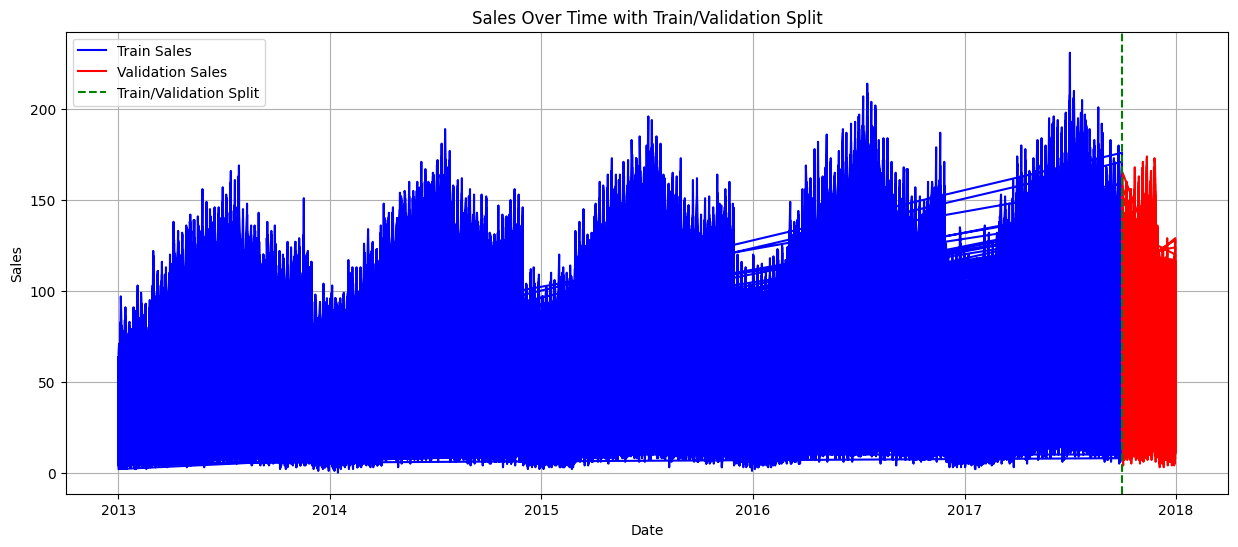

In [44]:
plt.figure(figsize=(15, 6))
plt.plot(train_data['date'], train_data['sales'], label='Train Sales', color='blue')
plt.plot(val_data['date'], val_data['sales'], label='Validation Sales', color='red')
plt.axvline(x=split_date, color='green', linestyle='--', label='Train/Validation Split')
plt.title('Sales Over Time with Train/Validation Split')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

### Exploring train-data

In [46]:
print(f'Number of items in each store: ')
train_data.groupby(['store'])['item'].nunique()

Number of items in each store: 


,item
store,
1,50
2,50
3,50
4,50
5,50
6,50
7,50
8,50
9,50


In [48]:
train_data.groupby(['store']).agg({'sales': ['count', 'sum', 'mean', 'median', 'std', 'min', 'max']})

sales                                               
       count      sum       mean median        std min  max
store                                                      
1      86700  4087626  47.146782   44.0  24.021180   1  155
2      86700  5796937  66.862018   62.0  33.625848   3  231
3      86700  5148794  59.386321   55.0  30.002082   3  196
4      86700  4748697  54.771592   51.0  27.755620   4  186
5      86700  3440051  39.677636   37.0  20.383615   2  130
6      86700  3436574  39.637532   37.0  20.329560   0  134
7      86700  3144946  36.273887   34.0  18.695770   1  122
8      86700  5546470  63.973126   59.0  32.254070   4  204
9      86700  4760726  54.910334   51.0  27.853057   4  195
10     86700  5078524  58.575825   54.0  29.583945   3  187

##### Cửa hàng số 2 và số 8 là những cửa hàng hoạt động tốt nhất. Xét về trung bình và tổng thể, họ đã bán được nhiều sản phẩm hơn. Hơn nữa, họ cũng ghi nhận mức bán tối đa cao nhất cho một sản phẩm trong một ngày.

In [50]:
train_data.groupby(['item']).agg({'sales': ['count', 'sum', 'mean', 'median', 'std', 'min', 'max']})

sales                                               
      count      sum       mean median        std min  max
item                                                      
1     17340   380279  21.930738   21.0   8.493474   1   59
2     17340  1013372  58.441292   56.0  20.196348   9  150
3     17340   633580  36.538639   35.0  13.216976   7  104
4     17340   380775  21.959343   21.0   8.433742   0   66
5     17340   317458  18.307843   18.0   7.284940   1   50
6     17340  1012229  58.375375   56.0  20.285715  11  148
7     17340  1012419  58.386332   56.0  20.231304  11  141
8     17340  1330591  76.735352   74.0  26.212315  15  181
9     17340   889407  51.292215   49.0  17.856501   6  134
10    17340  1266470  73.037486   70.0  24.921733  14  175
11    17340  1204076  69.439216   67.0  23.826938  11  170
12    17340  1204623  69.470761   67.0  23.856258  12  170
13    17340  1458659  84.121050   81.0  28.434935  20  210
14    17340  1014712  58.518570   56.0  20.166366  12  152
15    17340  1522523  87.804095   84.0  29.636305  17  231
16    17340   444008  25.605998   25.0   9.625600   2   70
17    17340   570957  32.927163   32.0  12.017801   4   83
18    17340  1457795  84.071223   81.0  28.550043  18  208
19    17340   698135  40.261534   39.0  14.397725   5   99
20    17340   821855  47.396482   46.0  16.566189   9  127
21    17340   697386  40.218339   39.0  14.386489   7  109
22    17340  1392447  80.302595   77.0  27.239295  14  214
23    17340   506631  29.217474   28.0  10.846056   3   81
24    17340  1142451  65.885294   63.0  22.609592  14  156
25    17340  1395857  80.499250   77.0  27.346709  18  193
26    17340   824196  47.531488   46.0  16.797824   8  119
27    17340   381659  22.010323   21.0   8.501799   1   59
28    17340  1519951  87.655767   84.0  29.614129  16  206
29    17340  1204305  69.452422   67.0  23.719337  15  173
30    17340   698057  40.257036   39.0  14.421680   5  115
31    17340  1014480  58.505190   56.0  20.209932  10  159
32    17340   760483  43.857151   42.0  15.612513   5  119
33    17340  1203632  69.413610   67.0  23.815582  15  169
34    17340   445042  25.665629   25.0   9.640583   2   79
35    17340  1138288  65.645213   63.0  22.566028  12  168
36    17340  1332082  76.821338   74.0  26.161563  16  188
37    17340   506023  29.182411   28.0  10.798582   3   74
38    17340  1392225  80.289792   77.0  27.217740  15  188
39    17340   758894  43.765513   42.0  15.556573   7  112
40    17340   505809  29.170069   28.0  10.860820   3   74
41    17340   380793  21.960381   21.0   8.415742   2   60
42    17340   634784  36.608074   35.0  13.264870   5   96
43    17340   886969  51.151615   49.0  17.858726   9  126
44    17340   508413  29.320242   28.0  10.833776   3   78
45    17340  1394116  80.398847   77.0  27.452065  18  205
46    17340  1013979  58.476298   56.0  20.290297  11  150
47    17340   380649  21.952076   21.0   8.449663   2   61
48    17340   888008  51.211534   49.0  17.951354   8  130
49    17340   507729  29.280796   28.0  10.921739   3   77
50    17340  1140084  65.748789   63.0  22.512606  12  164

#####Sản phẩm 28 và 15 là những sản phẩm được bán chạy nhất.

### Phân tích theo chuỗi thời gian

<Figure size 640x480 with 0 Axes>

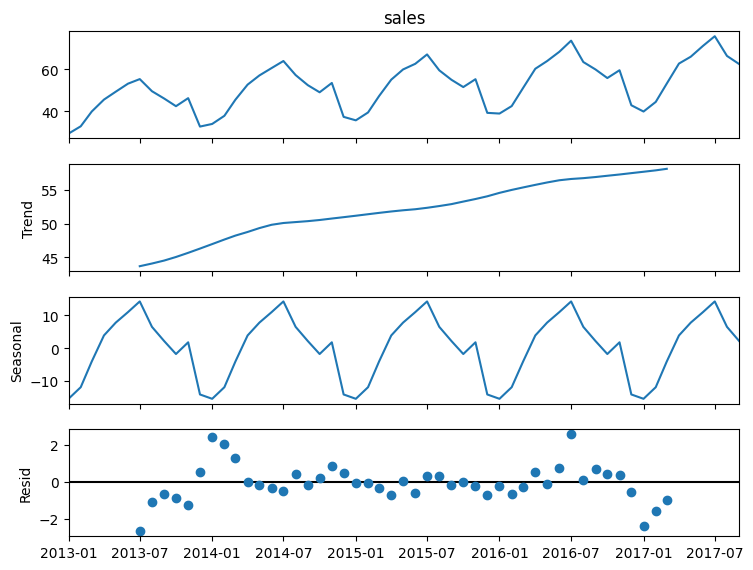

In [60]:
train_data = train_data.set_index('date')
monthly_avg_sales = train_data['sales'].resample('MS').mean()
ts_decomposition = sm.tsa.seasonal_decompose(monthly_avg_sales, model='additive')

fig = plt.figure()
fig = ts_decomposition.plot()
fig.set_size_inches(8, 6)


### Key insight:
Dựa trên phân tích phân rã chuỗi thời gian của doanh số trung bình hàng tháng, chúng ta có thể rút ra những hiểu biết sau:

Xu hướng dài hạn (Trend): Biểu đồ xu hướng cho thấy doanh số có xu hướng tăng trưởng ổn định qua các năm, cho thấy sự phát triển tích cực của hoạt động kinh doanh. Có một sự tăng trưởng rõ rệt từ năm 2013 đến cuối năm 2017.

Mô hình lặp lại theo mùa (Seasonality): Doanh số hiển thị một mô hình thời vụ mạnh mẽ và rõ ràng. Thường có sự sụt giảm doanh số vào đầu năm (tháng 1-2) và cuối năm (tháng 12), và đạt đỉnh vào giữa năm, đặc biệt là vào mùa hè (tháng 6-7). Mô hình này lặp lại nhất quán qua từng năm.

Biến động bất thường (Residuals): Phần dư cho thấy những biến động nhỏ sau khi loại bỏ xu hướng và tính thời vụ. Hầu hết các biến động này đều nằm trong một biên độ hẹp, cho thấy rằng xu hướng và tính thời vụ đã giải thích phần lớn sự biến động của doanh số. Không có biến động bất thường lớn hoặc đột biến đáng kể nào xuất hiện, cho thấy dữ liệu tương đối ổn định sau khi tính đến các yếu tố chu kỳ và xu hướng.

### Phân phối bán hàng

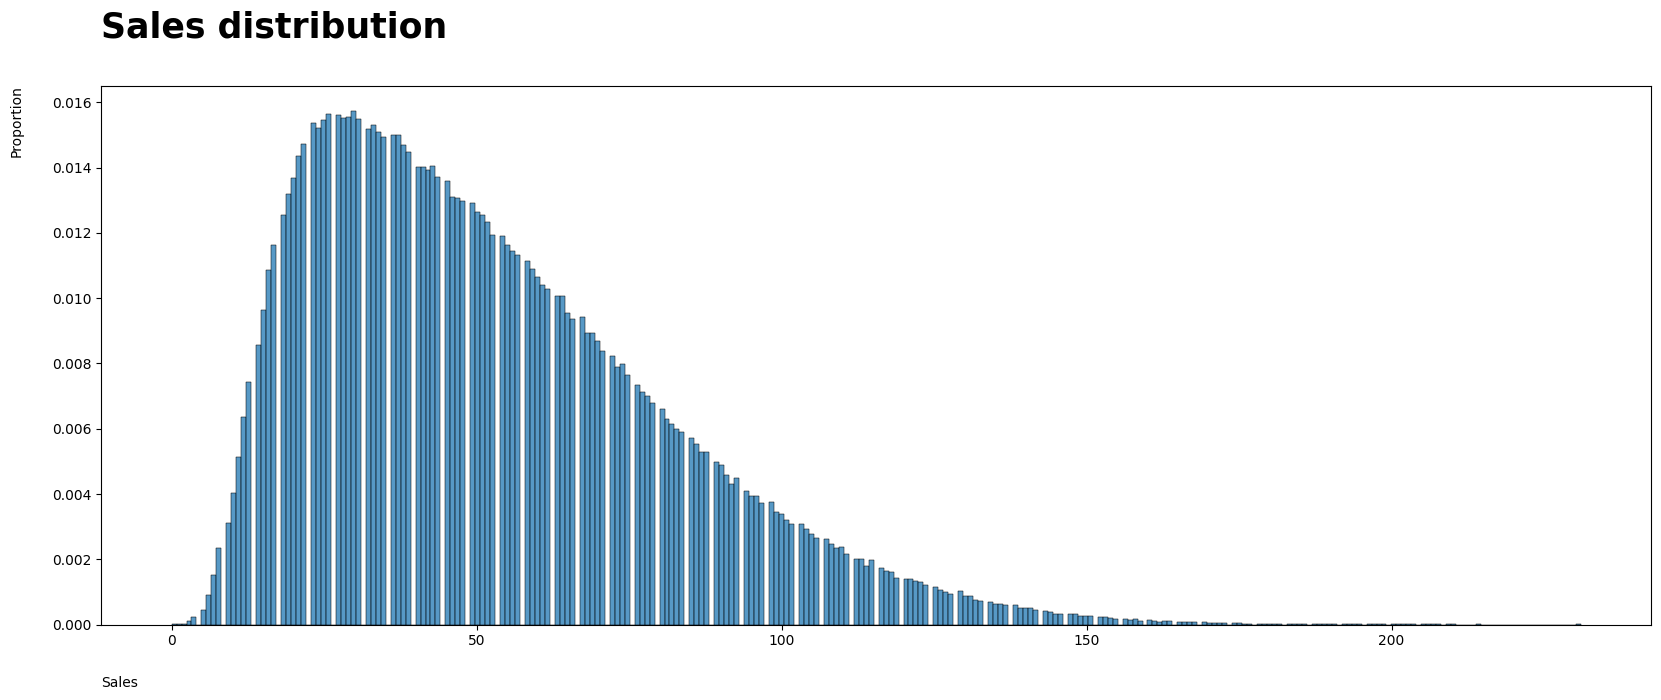

In [64]:
plt.figure(figsize=(20, 7))
sns.histplot(data=train_data, x='sales', stat='proportion')
plt.title('Sales distribution', loc='left', pad=35, fontsize=25, fontweight='bold')
plt.xlabel('Sales', loc='left', labelpad=20)
plt.ylabel('Proportion', loc='top', labelpad=20)
plt.show()

### Key insight:
1. Hình dạng phân phối (Shape): Biểu đồ cho thấy phân phối doanh số bán hàng là lệch phải (right-skewed). Điều này có nghĩa là phần lớn các giá trị doanh số tập trung ở mức thấp hơn, và có một 'đuôi' kéo dài về phía các giá trị doanh số cao hơn.

2. Độ lệch (Skewness): Phân phối có độ lệch dương đáng kể. Hầu hết các ngày, doanh số bán hàng có xu hướng nằm ở mức trung bình hoặc thấp hơn, với một số ít ngày có doanh số rất cao.

3. Giá trị doanh số điển hình (Typical Sales Values): Phần lớn doanh số bán hàng tập trung trong khoảng từ 0 đến khoảng 80-100 đơn vị. Đây là phạm vi mà mật độ dữ liệu cao nhất.

4. Giá trị ngoại lệ tiềm năng (Potential Outliers): Có một số lượng nhỏ các quan sát có doanh số vượt quá 150, thậm chí gần 200 hoặc hơn. Những giá trị này có thể được coi là các giá trị ngoại lệ hoặc doanh số đặc biệt cao, có thể do các sự kiện khuyến mãi, ngày lễ hoặc các yếu tố đặc biệt khác. Những giá trị này, mặc dù hiếm, nhưng góp phần tạo nên đuôi dài của phân phối.

### Doanh số bán hàng theo tháng trong năm

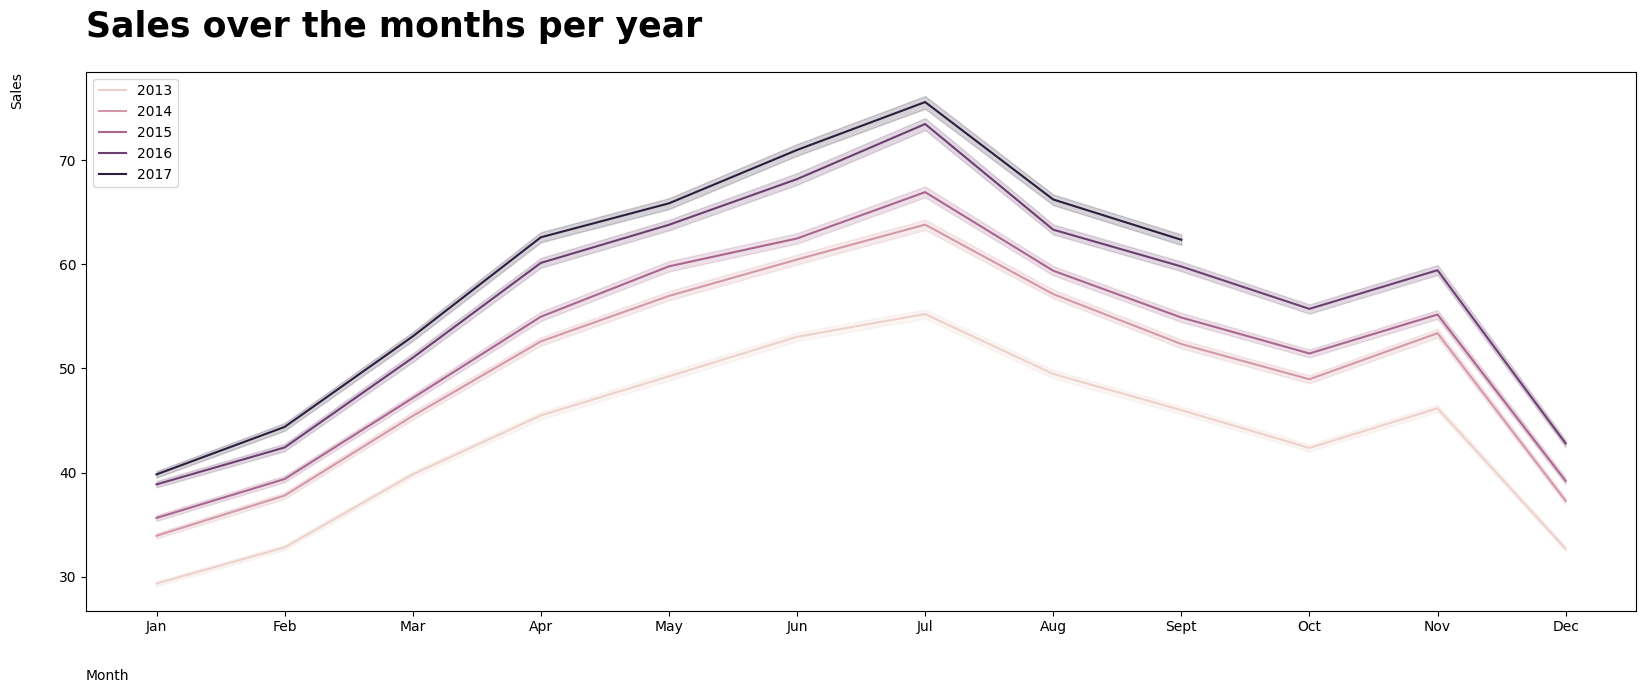

In [65]:
plt.figure(figsize=(20, 7))
sns.lineplot(data=train_data, x='month', y='sales', hue='year')
plt.title('Sales over the months per year', fontsize=25, fontweight='bold', loc='left', pad=25)
plt.xlabel('Month', loc='left', labelpad=25)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Sales', loc='top', labelpad=25)
plt.legend(loc='upper left')
plt.show()

### Key insight:
1. Mô hình tăng trưởng hàng năm: Biểu đồ cho thấy một xu hướng tăng trưởng doanh số tổng thể qua các năm. Doanh số trung bình cho mỗi tháng trong một năm cụ thể thường cao hơn so với cùng tháng của các năm trước. Ví dụ, đường doanh số của năm 2017 thường nằm trên các đường của các năm trước đó, minh chứng cho sự tăng trưởng liên tục.

2. Tính thời vụ hàng tháng: Doanh số thể hiện một mô hình thời vụ rất rõ ràng và lặp lại hàng năm:
Thấp điểm: Doanh số thường thấp nhất vào đầu năm (tháng 1, 2) và có xu hướng giảm nhẹ vào cuối năm (tháng 10, 11).
Cao điểm: Doanh số tăng dần từ tháng 3 và đạt đỉnh vào mùa hè (tháng 6, 7). Đây là giai đoạn các mặt hàng được bán chạy nhất trong năm.

3. Sụt giảm cuối năm: Sau đỉnh mùa hè, doanh số có xu hướng giảm dần qua các tháng cuối năm, mặc dù vẫn duy trì ở mức
cao hơn so với đầu năm.

4. Sự nhất quán của mô hình: Mô hình tăng trưởng và tính thời vụ này được lặp lại một cách nhất quán qua tất cả các năm (2013-2017), cho thấy một hành vi thị trường ổn định và có thể dự đoán được. Không có bất kỳ sự kiện ngoại lệ lớn nào làm thay đổi đáng kể mô hình này trong các năm được hiển thị.

### Doanh số bán hàng theo tuần trong năm

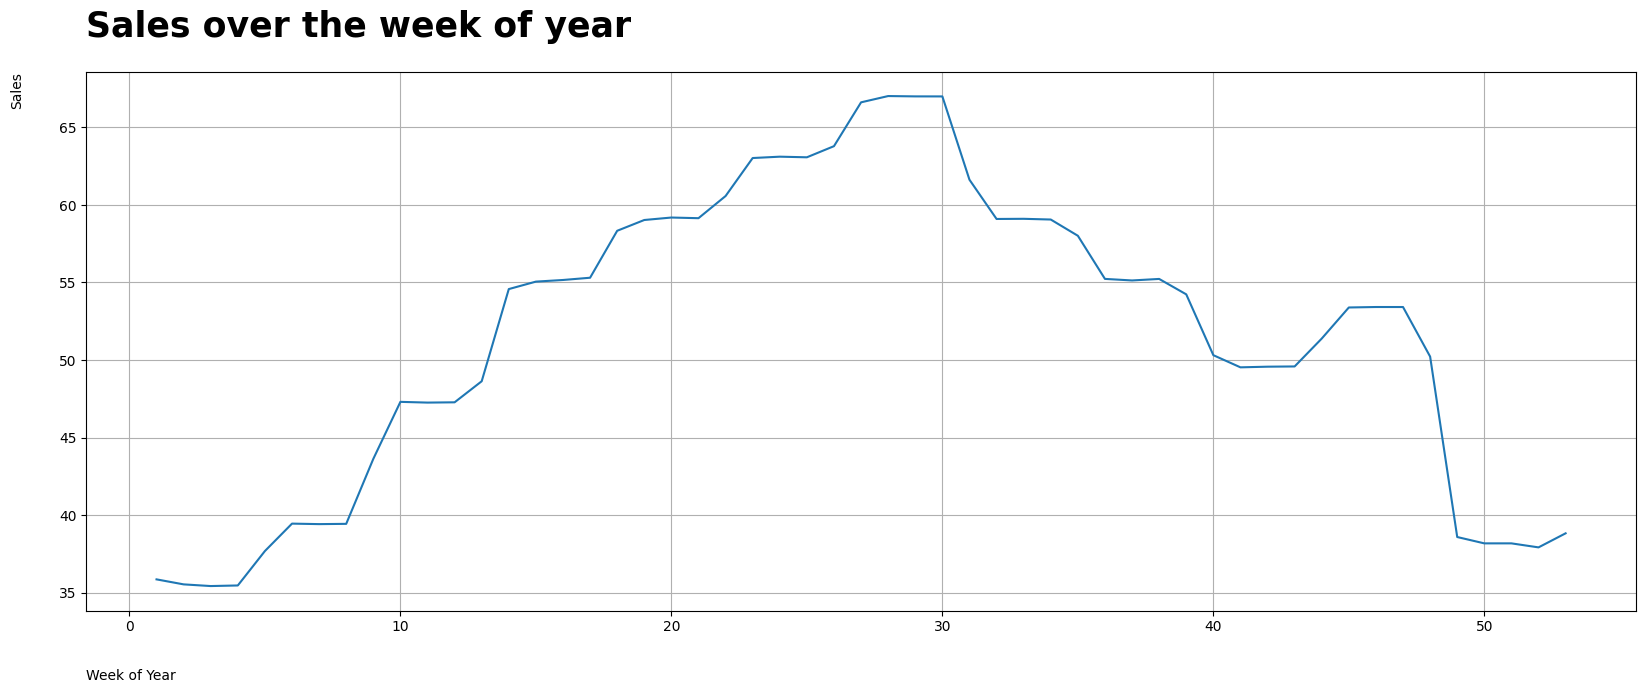

In [72]:
avg_sales_by_week = train_data.groupby('week_of_year')['sales'].mean()

plt.figure(figsize=(20, 7))
sns.lineplot(x=avg_sales_by_week.index, y=avg_sales_by_week.values)
plt.title('Sales over the week of year', fontsize=25, fontweight='bold', loc='left', pad=25)
plt.xlabel('Week of Year', loc='left', labelpad=25)
plt.ylabel('Sales', loc='top', labelpad=25)
plt.grid(True)
plt.show()

### Key insight:
1. Xu hướng chung theo tuần trong năm: Biểu đồ thể hiện rõ ràng xu hướng doanh số trung bình theo từng tuần trong năm, với một mô hình tăng trưởng và giảm rõ rệt theo mùa.

2. Giai đoạn thấp điểm: Doanh số thấp nhất vào đầu năm, đặc biệt là trong các tuần đầu tiên của tháng 1 (ví dụ, tuần 1-3). Giá trị thấp nhất là 35.42 (tuần 3), cho thấy một khởi đầu chậm chạp sau kỳ nghỉ lễ.

3. Giai đoạn tăng trưởng: Doanh số bắt đầu tăng mạnh từ cuối tháng 2 (tuần 9-10) và tiếp tục tăng ổn định cho đến giữa năm.

4. Giai đoạn cao điểm: Doanh số đạt đỉnh vào giữa năm, đặc biệt là vào các tháng mùa hè. Cao điểm nhất là vào tuần 28 với doanh số trung bình là 67.02, cho thấy nhu cầu mua sắm tăng cao trong mùa hè.

5. Giai đoạn suy giảm cuối năm: Sau đỉnh điểm mùa hè, doanh số có xu hướng giảm dần trong các tuần cuối năm, mặc dù có thể có những biến động nhỏ.

6. Tính mùa vụ mạnh mẽ: Mô hình này khẳng định tính mùa vụ mạnh mẽ của doanh số, với sự biến động đáng kể giữa các tuần trong năm.

### Doanh số bán hàng theo ngày trong tuần

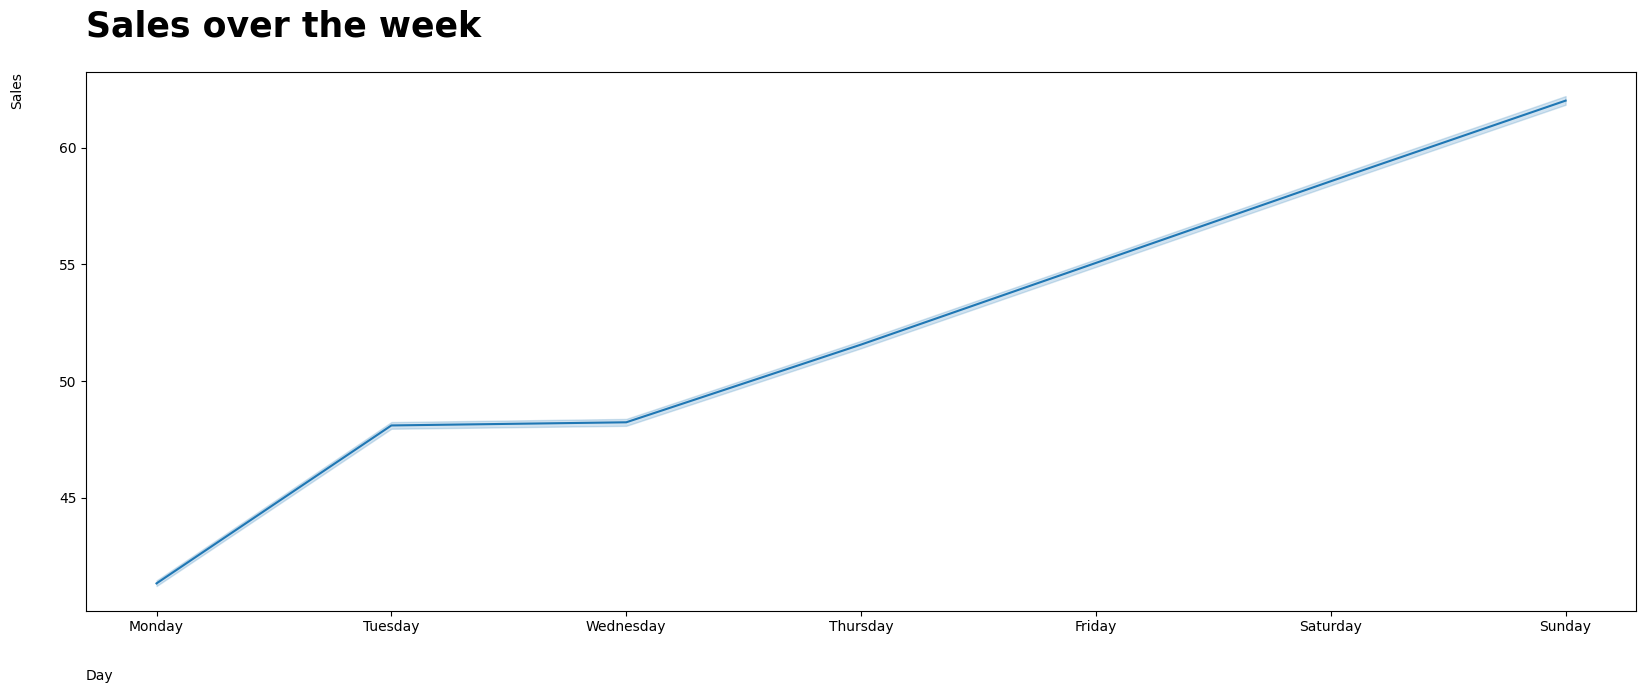

In [76]:
plt.figure(figsize=(20, 7))
sns.lineplot(data=train_data, x='day_of_week', y='sales')
plt.title('Sales over the week', fontsize=25, fontweight='bold', loc='left', pad=25)
plt.xlabel('Day', loc='left', labelpad=25)
plt.xticks(range(0, 7), ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.ylabel('Sales', loc='top', labelpad=25)
plt.show()

### Key insight:
1. Xu hướng chung trong tuần: Doanh số bán hàng có xu hướng tăng đều trong suốt tuần, bắt đầu từ đầu tuần và đạt đỉnh vào cuối tuần.

2. Ngày có doanh số thấp nhất: Thứ Hai (day_of_week = 0) có doanh số trung bình thấp nhất, với giá trị khoảng 41.32. Điều này cho thấy hoạt động kinh doanh thường chậm lại vào đầu tuần sau cuối tuần.

3. Ngày có doanh số cao nhất: Chủ Nhật (day_of_week = 6) có doanh số trung bình cao nhất, với giá trị khoảng 62.02. Điều này chỉ ra rằng cuối tuần, đặc biệt là Chủ Nhật, là thời điểm mua sắm bận rộn nhất.

4. Tăng trưởng liên tục: Có một sự tăng trưởng nhất quán từ Thứ Hai đến Chủ Nhật, cho thấy người tiêu dùng có xu hướng mua sắm nhiều hơn khi tuần tiến triển, với đỉnh điểm vào cuối tuần.

### Doanh số bán hàng theo ngày trong tháng

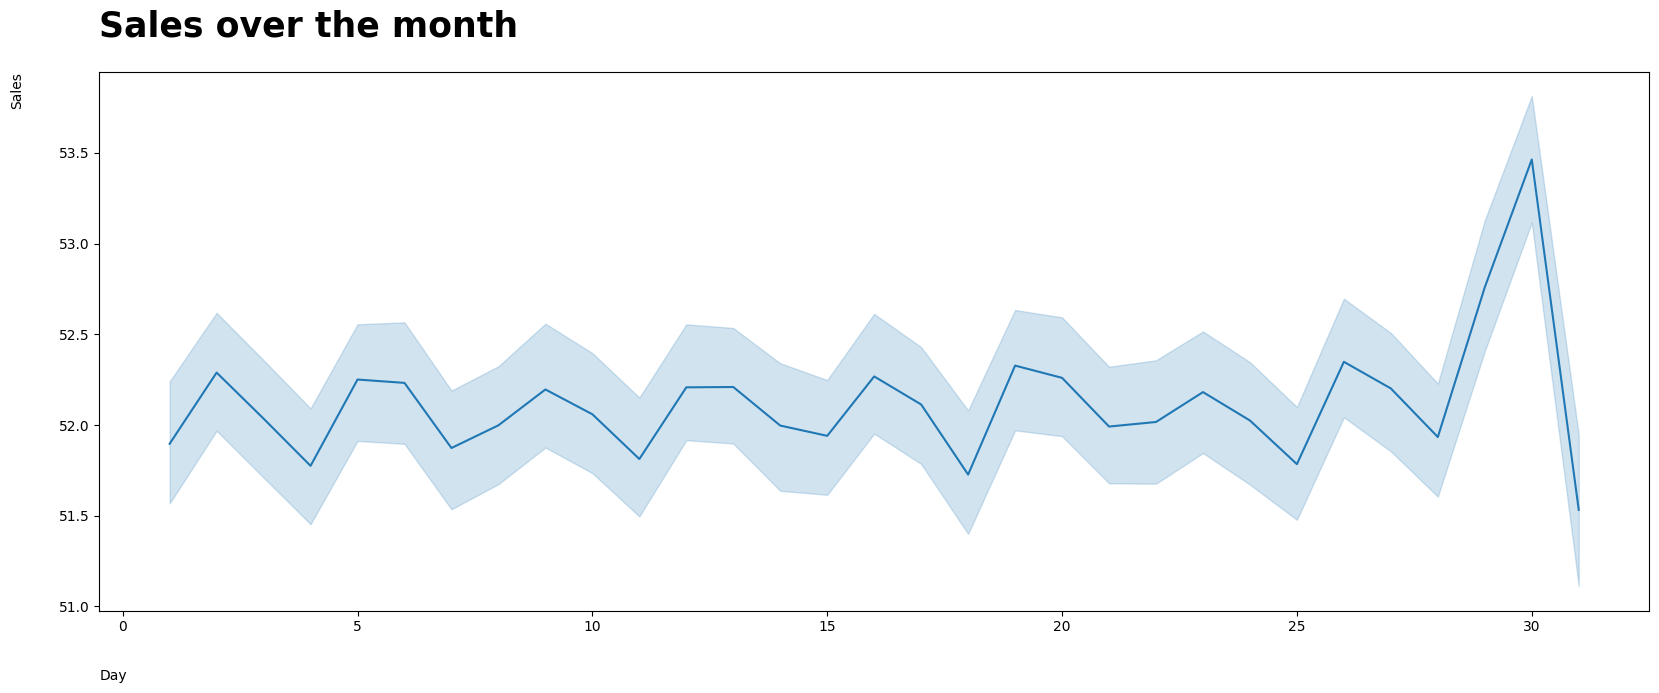

In [78]:
plt.figure(figsize=(20, 7))
sns.lineplot(data=train_data, x='day', y='sales')
plt.title('Sales over the month', fontsize=25, fontweight='bold', loc='left', pad=25)
plt.xlabel('Day', loc='left', labelpad=25)
plt.ylabel('Sales', loc='top', labelpad=25)
plt.show()

### Key insight:
1. Biến động liên tục (Continuous Fluctuations): Biểu đồ cho thấy doanh số bán hàng có xu hướng biến động liên tục trong suốt tháng, không có một xu hướng tăng hoặc giảm rõ rệt và nhất quán theo từng ngày như các biểu đồ theo tuần hoặc theo tháng. Thay vào đó, có sự lên xuống đều đặn.
2. Đỉnh điểm bán hàng (Sales Peaks): Doanh số thường đạt đỉnh vào khoảng đầu tháng (ngày 1-3), giữa tháng (ngày 15-18) và cuối tháng (ngày 28-31). Các đỉnh điểm này có thể liên quan đến các yếu tố như ngày nhận lương, các đợt khuyến mãi ngắn hạn, hoặc thói quen mua sắm theo chu kỳ hàng tháng của người tiêu dùng.
3. Thấp điểm bán hàng (Sales Troughs): Doanh số có xu hướng giảm nhẹ vào các ngày giữa các đỉnh điểm, ví dụ như từ ngày 5-10, hoặc ngày 20-25.
4. Sự tương đồng qua các chu kỳ: Mô hình biến động này khá nhất quán trong suốt các ngày của tháng, cho thấy một hành vi mua sắm có chu kỳ hàng tháng được lặp lại. Không có một ngày cụ thể nào trong tháng luôn vượt trội hoặc luôn thấp hơn hẳn các ngày khác một cách rõ rệt trên toàn bộ dữ liệu.
5. Ứng dụng: Hiểu biết này có thể giúp các cửa hàng lên kế hoạch tiếp thị, khuyến mãi hoặc quản lý hàng tồn kho hiệu quả hơn, tập trung vào các ngày dự kiến có doanh số cao.

### Doanh số bán hàng theo cửa hàng

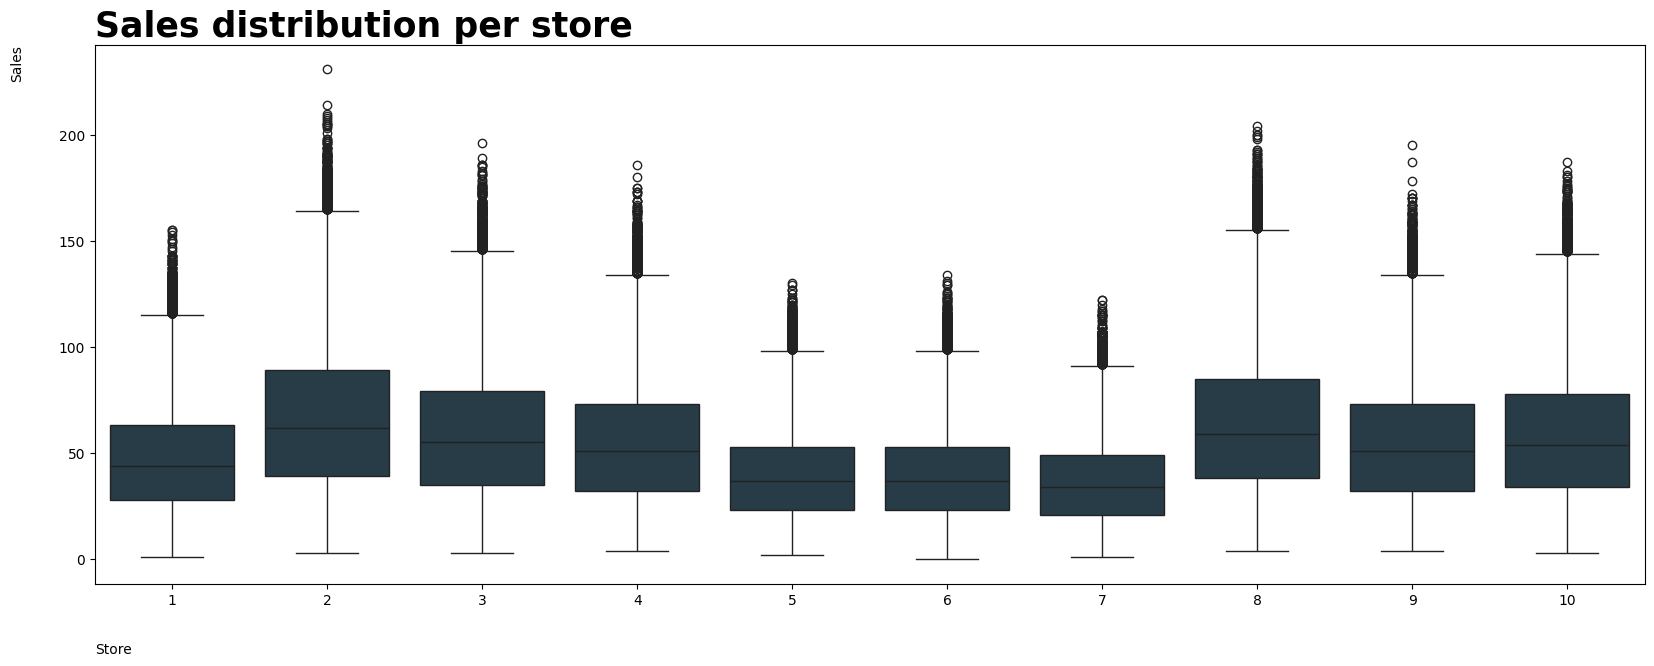

In [80]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=train_data, x='store', y='sales', color='#233D4D')
plt.title('Sales distribution per store', fontsize=25, fontweight='bold', loc='left')
plt.xlabel('Store', labelpad=25, loc='left')
plt.ylabel('Sales', labelpad=25, loc='top')
plt.show()

### Key insight:
1. Cửa hàng 2 và 8 nổi bật là những cửa hàng có doanh số trung bình và tổng cộng cao nhất. Cụ thể, cửa hàng 2 có doanh số trung bình là ~66.86 và cửa hàng 8 là ~63.97. Điều này cho thấy chúng là những cửa hàng hoạt động hiệu quả nhất.

2. Cửa hàng 7 có doanh số trung bình thấp nhất (~36.27), cho thấy hiệu suất bán hàng kém nhất trong số các cửa hàng.

### Doanh số bán hàng theo sản phẩm

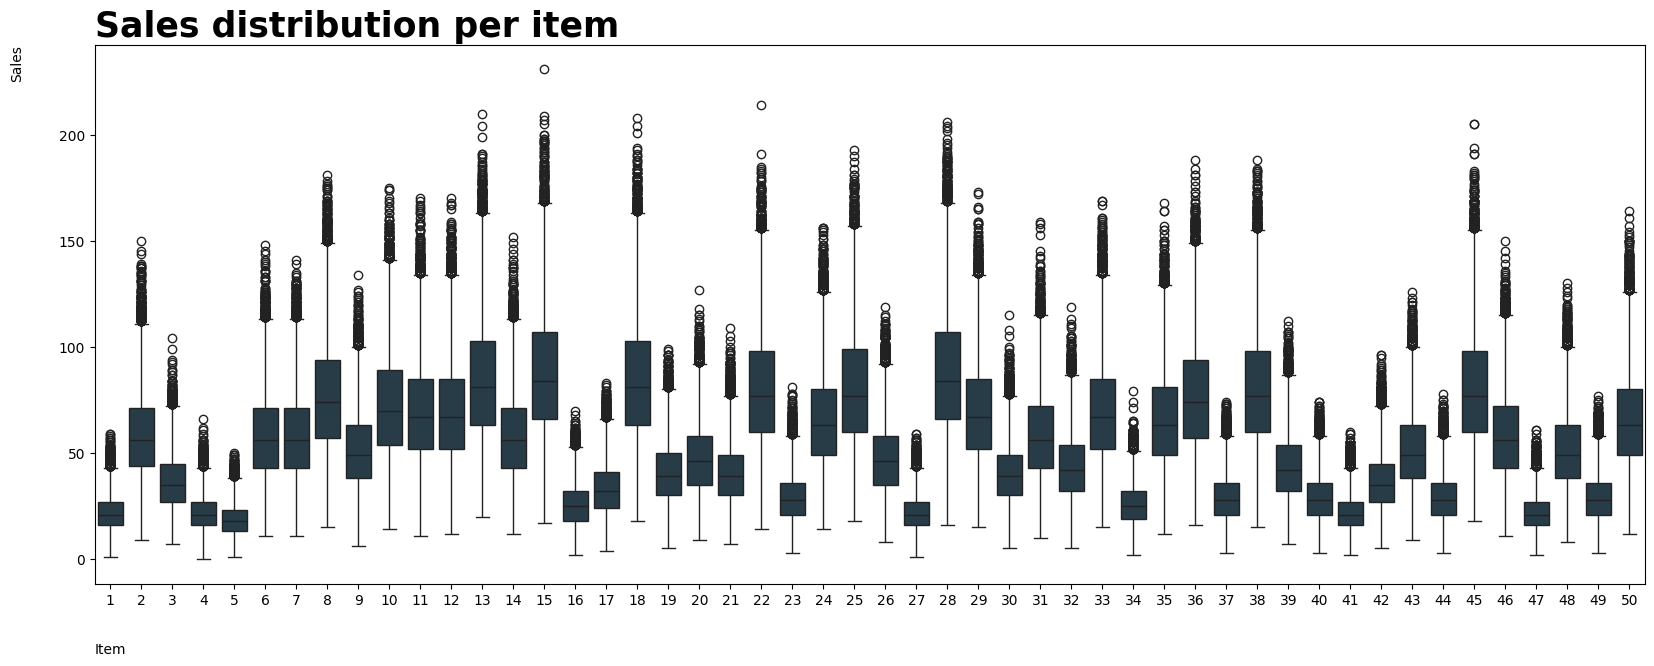

In [82]:
plt.figure(figsize=(20, 7))
sns.boxplot(data=train_data, x='item', y='sales', color='#233D4D')
plt.title('Sales distribution per item', fontsize=25, fontweight='bold', loc='left')
plt.xlabel('Item', labelpad=25, loc='left')
plt.ylabel('Sales', labelpad=25, loc='top')
plt.show()

### Key insight:
1. Các mặt hàng 15 và 28 là hai trong số những sản phẩm bán chạy nhất. Điều này được thể hiện rõ qua biểu đồ hộp (boxplot) và số liệu thống kê mô tả (descriptive statistics). Cả hai mặt hàng này đều có doanh số trung bình (mean sales) và tổng doanh số (total sales) cao nhất so với các mặt hàng khác, cho thấy nhu cầu thị trường mạnh mẽ.

2. Biểu đồ hộp cũng minh họa rằng các mặt hàng 15 và 28 có ngưỡng doanh số (median sales) cao và phạm vi bán hàng (sales range) rộng, với nhiều giao dịch có giá trị cao, thể hiện khả năng đạt được doanh số tối đa đáng kể.

### Xử lí Outlier

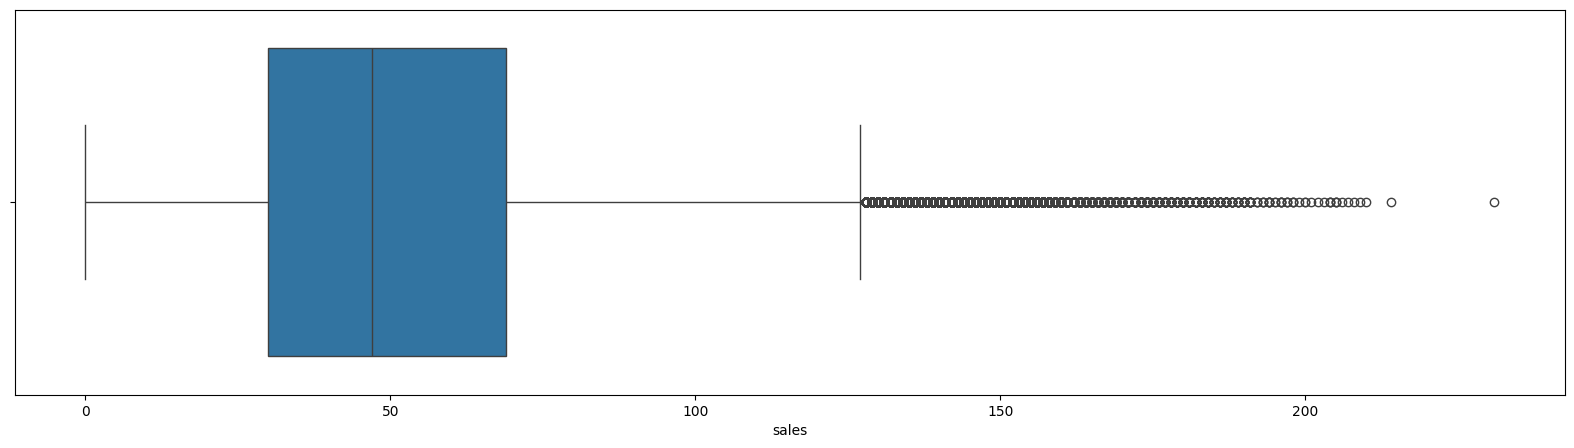

In [84]:
plt.figure(figsize=(20, 5))
sns.boxplot(data=train_data, x='sales')
plt.show()

In [92]:
train_data.loc[train_data['sales'] > 200, ['sales', 'store', 'day_of_week', 'month']]

,sales,store,day_of_week,month
date,,,,
2016-07-24,204,2,6,7
2017-07-09,210,2,6,7
2016-07-10,207,2,6,7
2016-07-17,209,2,6,7
2017-07-02,231,2,6,7
2017-07-09,205,2,6,7
2017-07-02,208,2,6,7
2017-07-08,204,2,5,7
2017-08-20,201,2,6,8


In [94]:
ax_sales = train_data['sales'].max()
print(f"Maximum sales value: {max_sales}")

max_sales_records = train_data[train_data['sales'] == max_sales]
max_sales_records[['sales', 'store', 'day_of_week', 'month']]

Maximum sales value: 231


,sales,store,day_of_week,month
date,,,,
2017-07-02,231,2,6,7


### Key conclusion:
Các giá trị Outlier không hề thể hiện những thông tin thiếu nhất quán. Có thể thấy rằng doanh số bán hàng cao nhất là ở cửa hàng số 2 và thường xảy ra vào những tháng hè, những thông tin này là hoàn toàn phù hợp với những phân tích từ EDA. Vì vậy ta có thể chấp nhận những giá trị Outlier này.

### **Kết luận sau khi phân tích EDA**:
**Xu hướng và Tính thời vụ của Doanh số**:

1. Xu hướng dài hạn: Doanh số bán hàng có xu hướng tăng trưởng ổn định qua từng năm (từ 2013 đến 2017), cho thấy sự phát triển tích cực của hoạt động kinh doanh.

2. Tính thời vụ hàng tháng/năm: Doanh số thể hiện mô hình thời vụ mạnh mẽ và nhất quán. Thường có sự sụt giảm vào đầu năm (tháng 1, 2) và cuối năm (tháng 12), và đạt đỉnh vào giữa năm, đặc biệt là vào mùa hè (tháng 6, 7).

3. Tính thời vụ hàng tuần: Doanh số thấp nhất vào đầu tháng 1 (tuần 1-3) và cao điểm nhất vào tuần 28 (giữa mùa hè).

4. Tính thời vụ hàng ngày: Trong tuần, doanh số thấp nhất vào Thứ Hai và cao nhất vào Chủ Nhật, với xu hướng tăng dần trong suốt tuần. Trong tháng, doanh số có sự biến động liên tục, thường đạt đỉnh vào đầu, giữa và cuối tháng, có thể liên quan đến ngày nhận lương hoặc các chương trình khuyến mãi.

**Phân phối Doanh số**:

1. Phân phối doanh số bán hàng lệch phải (right-skewed), cho thấy phần lớn các giao dịch có doanh số thấp đến trung bình (tập trung từ 0 đến khoảng 80-100 đơn vị). Tuy nhiên, có một số ít ngày hoặc giao dịch đạt mức doanh số rất cao, tạo thành một "đuôi" dài.

**Hiệu suất theo Cửa hàng và Sản phẩm**:

1. Cửa hàng: Cửa hàng số 2 và số 8 là những cửa hàng hoạt động hiệu quả nhất, có doanh số trung bình và tổng cộng cao nhất. Ngược lại, cửa hàng số 7 có hiệu suất thấp nhất.

2. Sản phẩm: Sản phẩm 15 và 28 là những mặt hàng bán chạy nhất, có doanh số trung bình và tổng thể cao nhất, cho thấy nhu cầu thị trường mạnh mẽ.